# Exploratory Data Analysis — K8s Metrics
Validate collected metrics and confirm anomalies are visible in the data.

In [1]:
import glob

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 5)

In [3]:
# Load all collected CSVs
files = glob.glob("../data/raw/metrics_*.csv")
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df["timestamp"] = pd.to_datetime(df["timestamp"]) - pd.Timedelta(hours=5)
df = df.sort_values("timestamp").reset_index(drop=True)
print(f"Total rows: {len(df)}")
print(f"Label distribution:\n{df['label'].value_counts()}")
df.head()

Total rows: 710
Label distribution:
label
normal     605
anomaly    105
Name: count, dtype: int64


,timestamp,pod,cpu_usage_rate,memory_working_set_bytes,network_receive_bytes_rate,network_transmit_bytes_rate,pod_ready,restart_delta,cpu_usage_rate_rolling_mean,cpu_usage_rate_rolling_std,...,network_receive_bytes_rate_rolling_mean,network_receive_bytes_rate_rolling_std,network_transmit_bytes_rate_rolling_mean,network_transmit_bytes_rate_rolling_std,pod_ready_rolling_mean,pod_ready_rolling_std,restart_delta_rolling_mean,restart_delta_rolling_std,label,collected_at
0,2026-04-09 06:16:28.802,api-service-c7945cfcb-bk9v8,0.000660,41902080.0,33.328060,54.190928,1.0,0.0,0.000660,0.0,...,33.328060,0.0,54.190928,0.0,1.0,0.0,0.0,0.0,normal,2026-04-09T11:46:28.967454
1,2026-04-09 06:16:28.802,stress-worker-696c8888c8-2kfbj,0.000000,262144.0,0.000000,0.240644,1.0,0.0,0.000000,0.0,...,0.000000,0.0,0.240644,0.0,1.0,0.0,0.0,0.0,normal,2026-04-09T11:46:28.967454
2,2026-04-09 06:16:28.802,api-service-c7945cfcb-sbfw2,0.000711,42131456.0,34.595846,56.769582,1.0,0.0,0.000711,0.0,...,34.595846,0.0,56.769582,0.0,1.0,0.0,0.0,0.0,normal,2026-04-09T11:46:28.967454
3,2026-04-09 06:16:28.802,web-frontend-5ffb76685b-ddcjg,0.000044,9310208.0,50.172159,152.144295,1.0,0.0,0.000044,0.0,...,50.172159,0.0,152.144295,0.0,1.0,0.0,0.0,0.0,normal,2026-04-09T11:46:28.967454
4,2026-04-09 06:16:28.802,web-frontend-5ffb76685b-ngwps,0.000050,9236480.0,46.539081,140.390785,1.0,0.0,0.000050,0.0,...,46.539081,0.0,140.390785,0.0,1.0,0.0,0.0,0.0,normal,2026-04-09T11:46:28.967454


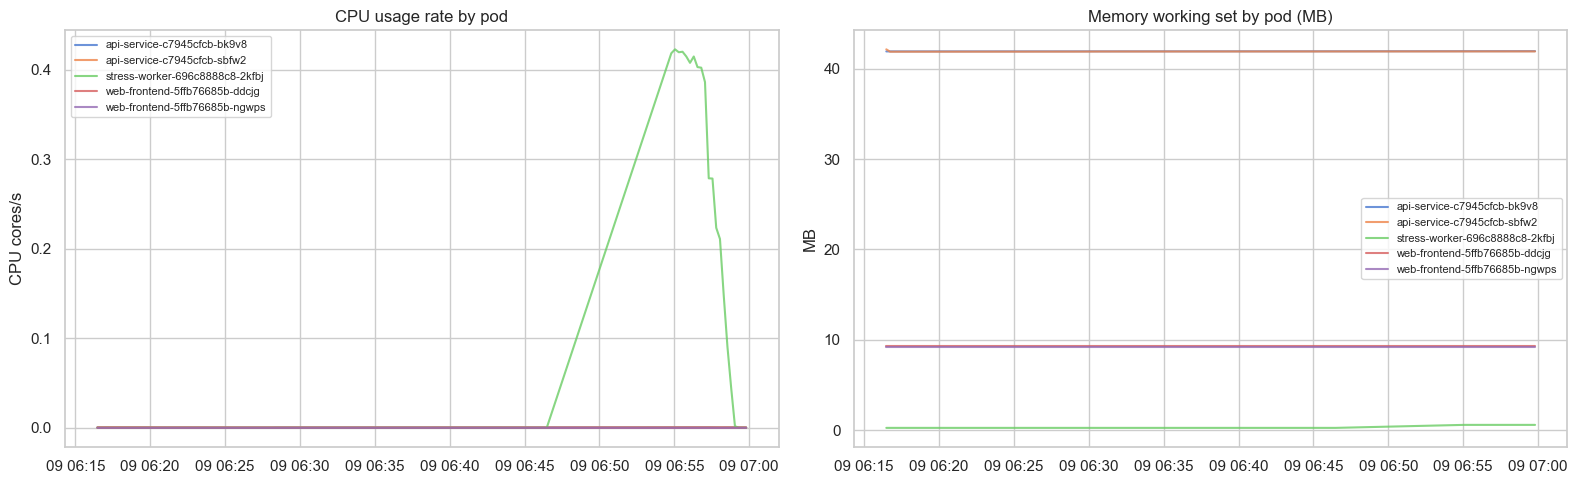

In [ ]:
# Plot CPU usage — anomalies should be visible as spikes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for pod, group in df.groupby("pod"):
    axes[0].plot(group["timestamp"], group["cpu_usage_rate"], label=pod, alpha=0.8)
axes[0].set_title("CPU usage rate by pod")
axes[0].set_ylabel("CPU cores/s")
axes[0].legend(fontsize=8)

for pod, group in df.groupby("pod"):
    axes[1].plot(
        group["timestamp"],
        group["memory_working_set_bytes"] / 1e6,
        label=pod,
        alpha=0.8,
    )
axes[1].set_title("Memory working set by pod (MB)")
axes[1].set_ylabel("MB")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../docs/eda_cpu_memory.png", dpi=150)
plt.show()

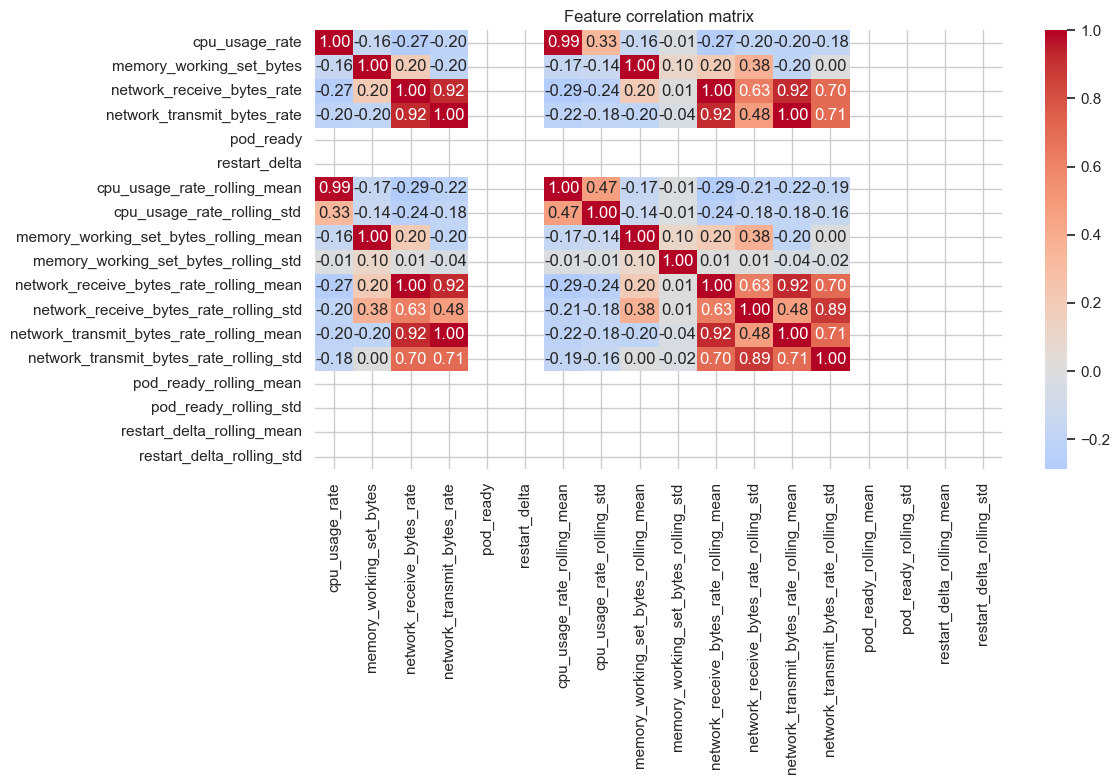

In [ ]:
# Feature correlation heatmap
numeric_cols = df.select_dtypes(include="number").columns
corr = df[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.savefig("../docs/eda_correlation.png", dpi=150)
plt.show()

In [7]:
# Summary statistics by label
feature_cols = [c for c in numeric_cols if c not in ["pod_ready"]]
df.groupby("label")[feature_cols].describe().round(4)

cpu_usage_rate                                                       \
                 count    mean     std  min     25%     50%     75%     max   
label                                                                         
anomaly          105.0  0.0516  0.1275  0.0  0.0001  0.0006  0.0008  0.4227   
normal           605.0  0.0003  0.0003  0.0  0.0000  0.0001  0.0006  0.0007   

        memory_working_set_bytes                ...  \
                           count          mean  ...   
label                                           ...   
anomaly                    105.0  2.059473e+07  ...   
normal                     605.0  2.052067e+07  ...   

        restart_delta_rolling_mean      restart_delta_rolling_std            \
                               75%  max                     count mean  std   
label                                                                         
anomaly                        0.0  0.0                     105.0  0.0  0.0   
normal                         0.0  0.0                     605.0  0.0  0.0   

                                  
         min  25%  50%  75%  max  
label                             
anomaly  0.0  0.0  0.0  0.0  0.0  
normal   0.0  0.0  0.0  0.0  0.0  

[2 rows x 136 columns]